В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

from ml_homework.metrics import root_mean_squared_error as rmse
from ml_homework.optimization import full_batch_gradient_descent
from ml_homework.paths import RAW_DATA_DIR
from ml_homework.visualization import plot_regression_predictions

medical_df = pd.read_csv(RAW_DATA_DIR / "medical/medical-charges.csv")
non_smoker_df = medical_df.loc[medical_df["smoker"] == "no"].copy()

In [2]:
non_smoker_df

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
...,...,...,...,...,...,...,...
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350


In [3]:
x = non_smoker_df["age"].values
y = non_smoker_df["charges"].values

w_mnk = np.sum((x - x.mean()) * (y - y.mean())) / np.sum((x - x.mean()) ** 2)
b_mnk = y.mean() - w_mnk * x.mean()

mnk_predictions = w_mnk * x + b_mnk
mnk_rmse = rmse(y, mnk_predictions)

print("w:", w_mnk)
print("b:", b_mnk)
print("RMSE:", mnk_rmse)
print("mnk_predictions:", mnk_predictions)

w: 267.2489128311996
b: -2091.4205565650846
RMSE: 4662.505766636395
mnk_predictions: [2719.0598744  5391.54900271 6727.79356686 ... 2719.0598744  2719.0598744
 3520.80661289]


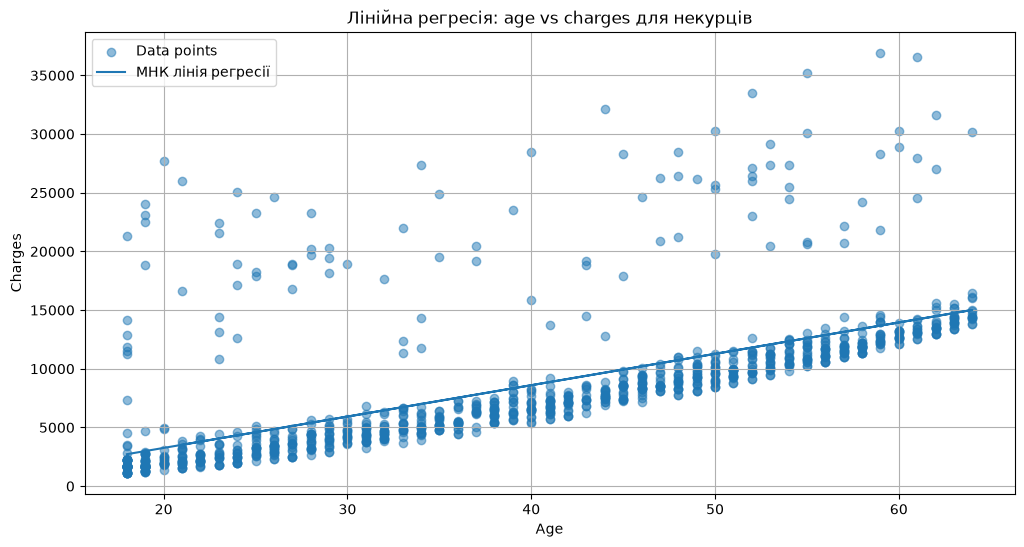

In [4]:
plot_regression_predictions(
    x,
    y,
    {"МНК лінія регресії": mnk_predictions},
    title="Лінійна регресія: age vs charges для некурців",
    xlabel="Age",
    ylabel="Charges",
)
plt.show()

In [5]:
X = non_smoker_df["age"].to_frame().to_numpy()
Y = non_smoker_df["charges"].to_numpy()
X, Y

(array([[18],
        [28],
        [33],
        ...,
        [18],
        [18],
        [21]], shape=(1064, 1)),
 array([ 1725.5523 ,  4449.462  , 21984.47061, ...,  2205.9808 ,
         1629.8335 ,  2007.945  ], shape=(1064,)))

In [6]:
learning_rates = [0.000001, 0.00001, 0.0001]

gd_results = []
gd_predictions = {}
gd_errors = {}

for lr in learning_rates:
    w_gd, b_gd, errors_gd = full_batch_gradient_descent(
        X, Y, learning_rate=lr, epochs=10000
    )

    predictions_gd = w_gd * X[:, 0] + b_gd
    rmse_gd = rmse(Y, predictions_gd)

    gd_results.append(
        {
            "learning_rate": lr,
            "w": w_gd,
            "b": b_gd,
            "RMSE": rmse_gd,
        }
    )

    gd_predictions[lr] = predictions_gd
    gd_errors[lr] = errors_gd

In [7]:
gd_results_df = pd.DataFrame(gd_results)
gd_results_df

,learning_rate,w,b,RMSE
0,0.000001,220.154555,0.213011,4715.349750
1,0.000010,221.104574,-41.980796,4713.250606
2,0.000100,229.612087,-419.830760,4696.325151


In [8]:
best_result = gd_results_df.loc[gd_results_df["RMSE"].idxmin()]

best_lr = best_result["learning_rate"]
best_w_gd = best_result["w"]
best_b_gd = best_result["b"]
best_rmse_gd = best_result["RMSE"]

best_gd_predictions = gd_predictions[best_lr]

print("Best learning rate:", best_lr)
print("w:", best_w_gd)
print("b:", best_b_gd)
print("RMSE:", best_rmse_gd)

Best learning rate: 0.0001
w: 229.6120874611436
b: -419.8307604133534
RMSE: 4696.325151433864


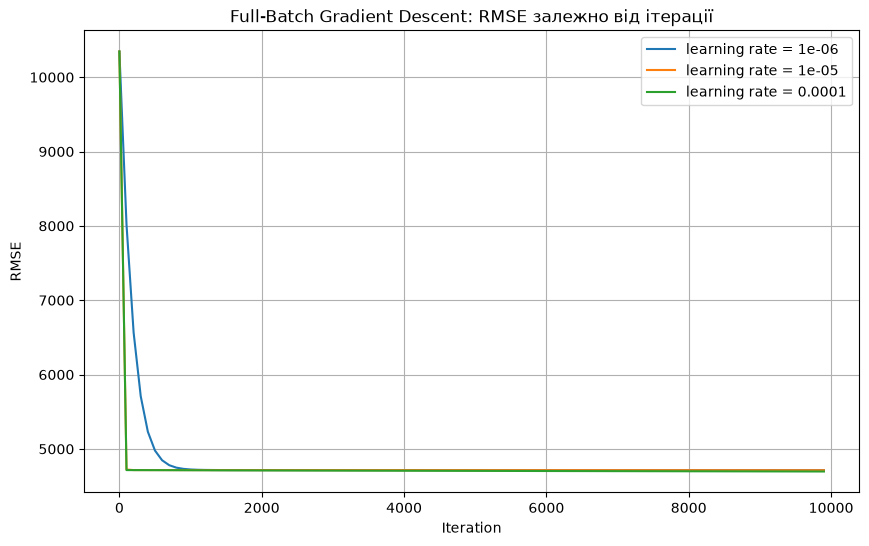

In [9]:
plt.figure(figsize=(10, 6))

for lr in learning_rates:
    errors = gd_errors[lr]

    plt.plot(range(0, len(errors), 100), errors[::100], label=f"learning rate = {lr}")

plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.title("Full-Batch Gradient Descent: RMSE залежно від ітерації")
plt.legend()
plt.grid(True)
plt.show()

Було протестовано три значення learning rate: 0.000001, 0.00001 та 0.0001.

Найкращий результат серед протестованих показав learning rate = 0.0001, оскільки після 10 000 ітерацій він дав найменший RMSE — приблизно 4696.33.

Для цього learning rate модель отримала коефіцієнти w ≈ 229.61 та b ≈ -419.83. Ці параметри ще відрізняються від результатів методу найменших квадратів (w ≈ 267.25, b ≈ -2091.42), тому градієнтний спуск ще не повністю зійшовся до оптимального розв’язку.

Менші значення learning rate навчаються повільніше, тому після однакової кількості ітерацій мають більший RMSE.

Отже, серед протестованих значень найкращим є learning rate = 0.0001.

In [10]:
lin_reg = LinearRegression()

In [11]:
lin_reg.fit(X, Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[267.25]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2091
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[459.17]


In [12]:
lin_reg.coef_, lin_reg.intercept_

(array([267.24891283]), np.float64(-2091.4205565650773))

In [13]:
predictions_sklearn = lin_reg.predict(X)

In [14]:
sklearn_rmse = rmse(Y, predictions_sklearn)

print("w:", lin_reg.coef_[0])
print("b:", lin_reg.intercept_)
print("RMSE:", sklearn_rmse)

w: 267.24891283119945
b: -2091.4205565650773
RMSE: 4662.505766636395


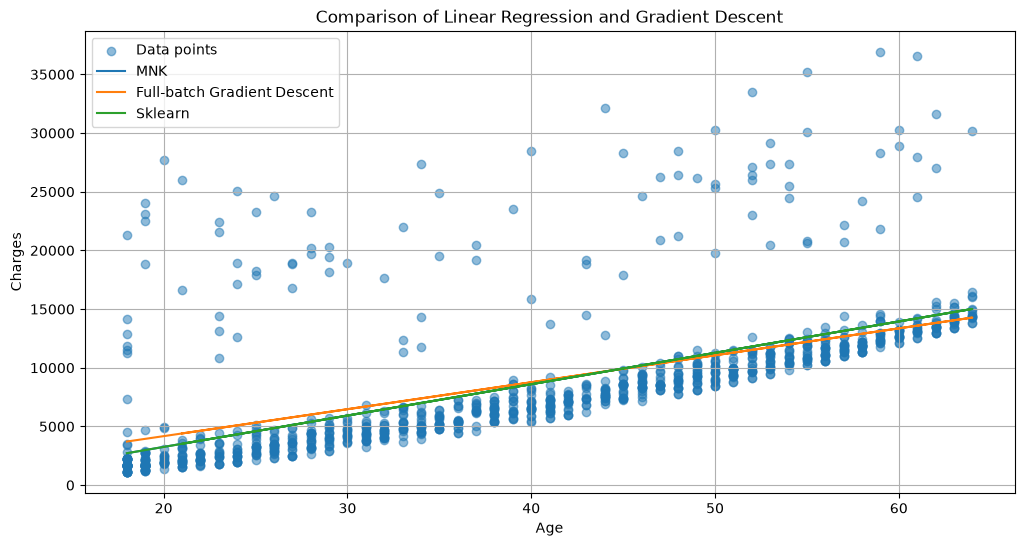

In [15]:
plot_regression_predictions(
    X[:, 0],
    Y,
    {
        "MNK": mnk_predictions,
        "Full-batch Gradient Descent": best_gd_predictions,
        "Sklearn": predictions_sklearn,
    },
    title="Comparison of Linear Regression and Gradient Descent",
    xlabel="Age",
    ylabel="Charges",
)
plt.show()

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [16]:
smoker_df = medical_df[medical_df.smoker == "yes"]

In [17]:
smoker_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
11,62,female,26.290,0,yes,southeast,27808.72510
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
...,...,...,...,...,...,...,...
1313,19,female,34.700,2,yes,southwest,36397.57600
1314,30,female,23.655,3,yes,northwest,18765.87545
1321,62,male,26.695,0,yes,northeast,28101.33305
1323,42,female,40.370,2,yes,southeast,43896.37630


In [18]:
X_smoker = smoker_df["age"].to_frame().to_numpy()
Y_smoker = smoker_df["charges"].to_numpy()

In [19]:
smoker_lin_reg = LinearRegression()

In [20]:
smoker_lin_reg.fit(X_smoker, Y_smoker)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[305.24]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.029e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[230.05]


In [21]:
smoker_lin_reg.coef_, smoker_lin_reg.intercept_

(array([305.23760211]), np.float64(20294.12812691597))

In [22]:
smoker_predictions_sklearn = smoker_lin_reg.predict(X_smoker)

In [23]:
smoker_sklearn_rmse = rmse(Y_smoker, smoker_predictions_sklearn)

print("w:", smoker_lin_reg.coef_[0])
print("b:", smoker_lin_reg.intercept_)
print("RMSE:", smoker_sklearn_rmse)

w: 305.23760210982874
b: 20294.12812691597
RMSE: 10711.00334810241


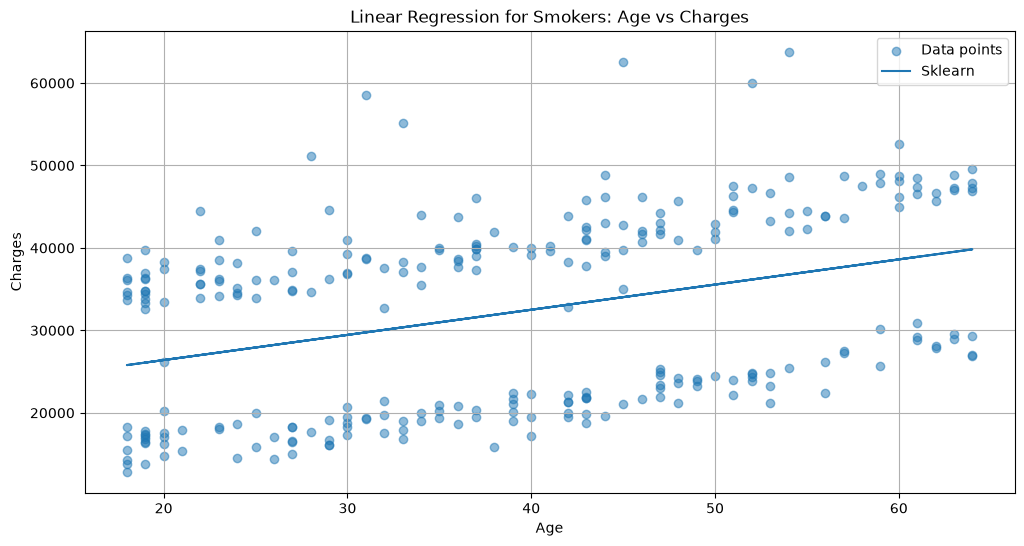

In [24]:
plot_regression_predictions(
    X_smoker[:, 0],
    Y_smoker,
    {"Sklearn": smoker_predictions_sklearn},
    title="Linear Regression for Smokers: Age vs Charges",
    xlabel="Age",
    ylabel="Charges",
)
plt.show()

Модель лінійної регресії для курців отримала коефіцієнт w ≈ 305.24 та вільний член b ≈ 20294.13. Це означає, що зі збільшенням віку на один рік прогнозовані медичні витрати курця в середньому збільшуються приблизно на 305.24.

RMSE моделі становить приблизно 10711.00, що є досить великою помилкою. На графіку видно значний розкид реальних значень навколо лінії регресії. Також помітно, що для однакового віку charges можуть дуже сильно відрізнятися.

Тому я не використовувала б цю модель у компанії як фінальну модель прогнозування. Вік сам по собі недостатньо добре пояснює медичні витрати курців.

Цю модель можна використати як базову для порівняння. Для покращення прогнозу варто додати інші ознаки, наприклад bmi, sex, children і region.